# Тихонов Илья

# Интеллектуальный анализ данных – весна 2026

# Домашнее задание 7: Деревья. Случайный лес

Правила:

- Домашнее задание оценивается в 10 баллов.


- Можно использовать без доказательства любые результаты, встречавшиеся на лекциях или семинарах по курсу, если получение этих результатов не является вопросом задания.


- Можно использовать любые свободные источники с обязательным указанием ссылки на них.


- Плагиат не допускается. При обнаружении случаев списывания, 0 за работу выставляется всем участникам нарушения, даже если можно установить, кто у кого списал.

<!-- ![](meme.jpg) -->
<img src="meme.jpg" alt="Drawing" style="width: 700px;"/>

## Часть 1: Основы построения решающие дерева (1.5 балла)

В этой части все расчёты необходимо реализовывать в виде запрограммированных формул, например, на `numpy`. **Нельзя использовать готовые реализации**. Например, если в задании требуется рассчитать энтропию, то требуется в каком-то виде релизовать расчёт по формуле, но нельзя использовать готовую реализацию `some_module.entropy()`.

In [104]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

**Задание 1.1 (0.5 балла)** Пусть известно, что в вершину решающего дерева попали 10 объектов, 8 из которых имеют метку класса $k_1$, а 2 имеют метку класса $k_2$. Рассчитайте энтропию такого распределения классов (с натуральным логарифмом). Ответ округлите до двух знаков после запятой.

In [105]:
probs = np.array([8 / 10, 2 / 10])
entropy = round(-np.sum(probs * np.log(probs)), 2)
entropy

np.float64(0.5)

**Задание 1.2 (0.5 балла)** Пусть дополнительно известно, что вершина из предыдущего задания не является листовой и возможно такое разбиение, что в левое поддерево попадут все объекты класса $k_1$, а в правое - класса $k_2$. Посчитайте критерий информативности:

$$
Q(R_m, j, t) = H(R_m) - \frac{|R_\ell|}{|R_m|}H(R_\ell) - \frac{|R_r|}{|R_m|}H(R_r),
$$

где $R_m$ - множество объектов в разбиваемой вершине, $j$ - номер признака, по которому происходит разбиение, $t$ - порог разбиения, $R_\ell$ - множество объектов в левом поддереве, $R_r$ - множество объектов в правом поддереве.

Теперь в качестве $H(R)$ будем использовать индекс Джини:

$$
H(R) = \sum_{k=1}^J p_k(1-p_k),
$$
где $J$ – общее количество классов (в нашем случае, $J = 2$).

Ответ округлите до двух знаков после запятой.

In [106]:
def gini_from_counts(counts):
    counts = np.array(counts, dtype=float)
    probs = counts / counts.sum()
    return np.sum(probs * (1 - probs))

parent_gini = gini_from_counts([8, 2])
left_gini = gini_from_counts([8, 0])
right_gini = gini_from_counts([0, 2])

Q = parent_gini - (8 / 10) * left_gini - (2 / 10) * right_gini
print(round(Q, 2))

0.32


**Задание 1.3 (0.5 балла)** Пусть при построении дерева образовалась листовая вершина с 10 объектами, значения целевой переменной для которых следующие: [1, 10, 5, 18, 100, 30, 50, 61, 84, 47] (решается задача регрессии). Чему будут равны предсказания модели для этих объектов?

In [107]:
y_leaf = np.array([1, 10, 5, 18, 100, 30, 50, 61, 84, 47])
leaf_prediction = np.mean(y_leaf)
predictions = np.full_like(y_leaf, fill_value=leaf_prediction, dtype=float)
print(leaf_prediction)
print(predictions)

40.6
[40.6 40.6 40.6 40.6 40.6 40.6 40.6 40.6 40.6 40.6]


## Часть 2: Решающие деревья (4.5 балла)

В этой части мы напишем и протестируем собственную реализацию решающего дерева.

In [108]:
from collections import Counter
from typing import Dict, List, Tuple, Union

**Задание 2.1 (1.5 балла)** Реализуйте функцию `find_best_split()`, которая должна находить оптимальное разбиение подмножества обучающей выборки в соответствии с информационным критерием из **Задания 1.2**. В качестве меры хаотичности $H(R)$ для задачи регрессии испольуйте дисперсию подвыборки, а для задачи классификации – критерий Джини (определён в том же задании).

Для категориальных признаков применяется наивный алгоритм разбиения: мы пытаемся найти одно значение, разбиение по которому сильнее всего увеличит критерий информативности. Иными словами, объекты с конкретным значением признака отправляем в левое поддерево, остальные - в правое. Обратите внимание, что это далеко не оптимальные способ учёта категориальных признаков. Например, можно было бы на каждое значение категориального признака создавать отдельное поддерево или использовать более сложные подходы. Подробнее об этом можно прочитать в конспектах [лекций](https://github.com/esokolov/ml-course-hse/blob/master/2019-fall/lecture-notes/lecture07-trees.pdf) по машинному обучению на ПМИ (раздел «Учёт категориальных признаков»).

В качестве подсказок реализации можете пользоваться кодом из бонусной части семинара по решающим деревьям.

**Бонус:** Разрешается делать цикл для перебора порогов, но возможна имплементация без него. За имплементацию без цикла – **бонус 1 балл**.

In [109]:
def classification_impurity(counts: np.ndarray) -> np.ndarray:
    counts = np.asarray(counts, dtype=float)
    totals = counts.sum(axis=-1, keepdims=True)
    probs = np.divide(counts, totals, out=np.zeros_like(counts, dtype=float), where=totals != 0)
    return np.sum(probs * (1 - probs), axis=-1)


def regression_impurity(counts: np.ndarray, sums: np.ndarray, sums_sq: np.ndarray) -> np.ndarray:
    counts = np.asarray(counts, dtype=float)
    means = np.divide(sums, counts, out=np.zeros_like(sums, dtype=float), where=counts != 0)
    second_moments = np.divide(sums_sq, counts, out=np.zeros_like(sums_sq, dtype=float), where=counts != 0)
    return np.maximum(second_moments - means ** 2, 0.0)


def find_best_split(
    feature_vector: Union[np.ndarray, pd.Series, pd.DataFrame], 
    target_vector: Union[np.ndarray, pd.Series],
    task: str = "classification",
    feature_type: str = "real"
) -> Tuple[np.ndarray, np.ndarray, float, float]:
    """
    Указания:
    * Пороги, приводящие к попаданию в одно из поддеревьев пустого множества объектов, не рассматриваются.
    * В качестве порогов, нужно брать среднее двух сосдених (при сортировке) значений признака
    * Поведение функции в случае константного признака может быть любым.
    * При одинаковых приростах Джини или дисперсии нужно выбирать минимальный сплит.
    * За наличие в функции циклов балл будет снижен. Векторизуйте! :)

    :param feature_vector: вещественнозначный вектор значений признака
    :param target_vector: вектор классов объектов,  len(feature_vector) == len(target_vector)
    :param task: либо `classification`, либо `regression`
    :param feature_type: либо `real`, либо `categorical`

    :return thresholds: отсортированный по возрастанию вектор со всеми возможными порогами, по которым объекты можно
     разделить на две различные подвыборки, или поддерева
    :return ginis: вектор со значениями критерия Джини для каждого из порогов в thresholds len(ginis) == len(thresholds)
    :return threshold_best: оптимальный порог (число)
    :return gini_best: оптимальное значение критерия Джини (число)
    """
    x = np.asarray(feature_vector).reshape(-1)
    y = np.asarray(target_vector).reshape(-1)

    n = len(y)
    if task == "classification":
        classes, y_idx = np.unique(y, return_inverse=True)
        one_hot = np.eye(len(classes), dtype=float)[y_idx]
        parent_counts = one_hot.sum(axis=0)
        parent_impurity = classification_impurity(parent_counts)
    else:
        y_float = y.astype(float)
        parent_impurity = float(np.var(y_float))

    if feature_type == "real":
        x_float = x.astype(float)
        order = np.argsort(x_float, kind="mergesort")
        x_sorted = x_float[order]
        y_sorted = y[order]

        valid_positions = np.flatnonzero(x_sorted[1:] != x_sorted[:-1]) + 1

        thresholds = (x_sorted[valid_positions - 1] + x_sorted[valid_positions]) / 2
        left_sizes = valid_positions.astype(float)
        right_sizes = (n - valid_positions).astype(float)

        if task == "classification":
            sorted_one_hot = one_hot[order]
            cumsum_counts = np.cumsum(sorted_one_hot, axis=0)
            left_counts = cumsum_counts[valid_positions - 1]
            right_counts = parent_counts - left_counts
            left_impurity = classification_impurity(left_counts)
            right_impurity = classification_impurity(right_counts)
        else:
            y_sorted = y_sorted.astype(float)
            cumsum_y = np.cumsum(y_sorted)
            cumsum_y2 = np.cumsum(y_sorted ** 2)
            total_sum = cumsum_y[-1]
            total_sum2 = cumsum_y2[-1]
            left_sum = cumsum_y[valid_positions - 1]
            left_sum2 = cumsum_y2[valid_positions - 1]
            right_sum = total_sum - left_sum
            right_sum2 = total_sum2 - left_sum2
            left_impurity = regression_impurity(left_sizes, left_sum, left_sum2)
            right_impurity = regression_impurity(right_sizes, right_sum, right_sum2)

        gains = parent_impurity - (left_sizes / n) * left_impurity - (right_sizes / n) * right_impurity

    else:
        thresholds = np.unique(x)
        masks = x[:, None] == thresholds[None, :]
        left_sizes = masks.sum(axis=0).astype(float)
        right_sizes = n - left_sizes
        valid = (left_sizes > 0) & (right_sizes > 0)
        thresholds = thresholds[valid]
        masks = masks[:, valid]
        left_sizes = left_sizes[valid]
        right_sizes = right_sizes[valid]
        if thresholds.size == 0:
            return np.array([]), np.array([]), None, None

        if task == "classification":
            left_counts = masks.T.astype(float) @ one_hot
            right_counts = parent_counts - left_counts
            left_impurity = classification_impurity(left_counts)
            right_impurity = classification_impurity(right_counts)
        else:
            y_float = y.astype(float)
            total_sum = y_float.sum()
            total_sum2 = np.sum(y_float ** 2)
            left_sum = masks.T.astype(float) @ y_float
            left_sum2 = masks.T.astype(float) @ (y_float ** 2)
            right_sum = total_sum - left_sum
            right_sum2 = total_sum2 - left_sum2
            left_impurity = regression_impurity(left_sizes, left_sum, left_sum2)
            right_impurity = regression_impurity(right_sizes, right_sum, right_sum2)

        gains = parent_impurity - (left_sizes / n) * left_impurity - (right_sizes / n) * right_impurity

    best_idx = int(np.argmax(gains))
    return thresholds, gains, thresholds[best_idx], float(gains[best_idx])

Эту функцию можно протестировать на датасете `California`.

In [110]:
from sklearn.datasets import fetch_california_housing

In [111]:
data = fetch_california_housing()
X = pd.DataFrame(data=data["data"], columns=data["feature_names"])
y = data["target"]
print("Loaded California Housing dataset", X.shape)
X.head()

Loaded California Housing dataset (20640, 8)


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25


In [112]:
y

array([4.526, 3.585, 3.521, ..., 0.923, 0.847, 0.894], shape=(20640,))

Выведите график зависимости значения критерия ошибки от порогового значения при разбиении вершины по признаку `MedInc`.

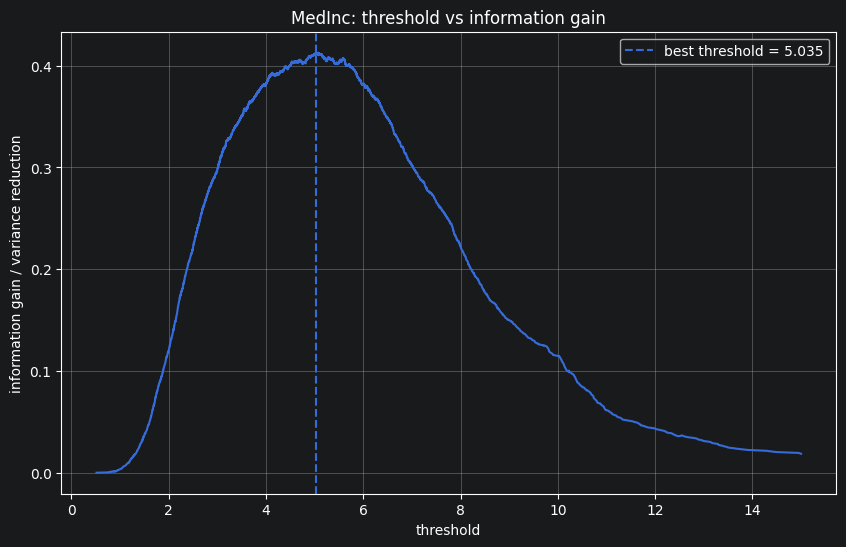

,feature,best_threshold,best_gain
0,MedInc,5.03515,0.412751


In [113]:
thresholds_medinc, gains_medinc, best_threshold_medinc, best_gain_medinc = find_best_split(
    X["MedInc"].values, y, task="regression", feature_type="real"
)

plt.figure(figsize=(10, 6))
plt.plot(thresholds_medinc, gains_medinc)
plt.axvline(best_threshold_medinc, linestyle="--", label=f"best threshold = {best_threshold_medinc:.3f}")
plt.title("MedInc: threshold vs information gain")
plt.xlabel("threshold")
plt.ylabel("information gain / variance reduction")
plt.legend()
plt.grid(True)
plt.show()

medinc_split_df = pd.DataFrame([{
    "feature": "MedInc",
    "best_threshold": best_threshold_medinc,
    "best_gain": best_gain_medinc,
}])
display(medinc_split_df)

Найдите лучший, с вашей точки зрения, предикат первой вершины решающего дерева.

In [114]:
best_splits = []
for feature_name in X.columns:
    _, _, threshold, gain = find_best_split(X[feature_name].values, y, task="regression", feature_type="real")
    best_splits.append({"feature": feature_name, "threshold": threshold, "gain": gain})

best_splits_df = pd.DataFrame(best_splits).sort_values("gain", ascending=False).reset_index(drop=True)
display(best_splits_df)


,feature,threshold,gain
0,MedInc,5.035150,0.412751
1,AveRooms,6.374305,0.159208
2,Latitude,37.935000,0.090334
3,AveOccup,3.112543,0.073919
4,Longitude,-121.865000,0.050211
5,HouseAge,51.500000,0.030901
6,AveBedrms,1.103378,0.015253
7,Population,1160.500000,0.002831


Лучший первый предикат: `MedInc < 5.035`. Он выбран потому, что среди всех признаков даёт максимальный прирост информативности (`gain = 0.412751`). Для задачи регрессии это означает, что такое разбиение сильнее всего уменьшает взвешенную дисперсию целевой переменной в дочерних вершинах. Поэтому после разбиения по `MedInc` значения `target` внутри поддеревьев становятся более однородными, чем при разбиении по другим признакам

**Задание 2.2 (1 балл)** Разберитесь с написанным кодом решающего дерева, заполните пропуски в коде и реализуйте недостающий метод `_predict_node()`.

Построение дерева осуществляется согласно базовому жадному алгоритму, предложенному в лекции в разделе «Построение дерева».
- **Выбор лучшего разбиения** необходимо производить по критерию Джини.
- **Критерий останова:** все объекты в листе относятся к одному классу или ни по одному признаку нельзя разбить выборку.
- **Ответ в листе:** наиболее часто встречающийся класс в листе.

В задаче также предлагается получить два бонуса, по баллу на каждый!

- **Реализуйте способ обрабатывать пропуски в даннх и реализуйте его, пояснив свои действия.**
- **Реализуйте метод оценки важности признаков.**

In [115]:
class DecisionTree:
    
    def __init__(
        self, 
        feature_types: Union[List[str], np.ndarray], 
        max_depth: int = None, 
        min_samples_split: int = None, 
        min_samples_leaf: int = None,
        task: str = "classification"
    ) -> None:
        
        if np.any(list(map(lambda x: x != "real" and x != "categorical", feature_types))):
            raise ValueError("There is unknown feature type")
        if task not in {"classification", "regression"}:
            raise ValueError("task must be 'classification' or 'regression'")

        self._tree = {}
        self._feature_types = list(feature_types)
        self._max_depth = max_depth
        self._min_samples_split = min_samples_split
        self._min_samples_leaf = min_samples_leaf
        self.task = task
        self._feature_importances = {}
        self._fill_values = None
        self._n_features = None

    def _make_terminal(self, sub_y: np.ndarray, node: dict) -> None:
        node["type"] = "terminal"
        if self.task == "classification":
            node["class"] = Counter(sub_y).most_common(1)[0][0]
        else:
            node["class"] = float(np.mean(sub_y))

    def _calc_fill_values(self, X: np.ndarray) -> List[object]:
        """
        Бонусная обработка пропусков: вещественные признаки заполняем медианой,
        категориальные модой
        """
        fill_values = []
        for j, feature_type in enumerate(self._feature_types):
            col = X[:, j]
            missing = pd.isnull(col)
            valid = col[~missing]
            if feature_type == "real":
                fill_values.append(float(np.nanmedian(valid.astype(float))) if len(valid) else 0.0)
            else:
                fill_values.append(Counter(valid).most_common(1)[0][0] if len(valid) else "__missing__")
        return fill_values

    def _apply_fill_values(self, X: np.ndarray) -> np.ndarray:
        X_filled = np.asarray(X, dtype=object).copy()
        for j, fill_value in enumerate(self._fill_values):
            missing = pd.isnull(X_filled[:, j])
            if np.any(missing):
                X_filled[missing, j] = fill_value
        return X_filled

    def _fit_node(
        self, 
        sub_X: np.ndarray, 
        sub_y: np.ndarray, 
        node: dict,
        depth: int = 0
    ) -> None:
        
        if len(sub_y) == 0:
            raise ValueError("Attempted to fit an empty node")
        if np.all(sub_y == sub_y[0]):
            self._make_terminal(sub_y, node)
            return
        if self._max_depth is not None and depth >= self._max_depth:
            self._make_terminal(sub_y, node)
            return
        if self._min_samples_split is not None and len(sub_y) < self._min_samples_split:
            self._make_terminal(sub_y, node)
            return

        feature_best, threshold_best, gini_best, split = None, None, None, None
        for feature in range(sub_X.shape[1]):
            feature_type = self._feature_types[feature]

            if feature_type == "real":
                feature_vector = sub_X[:, feature].astype(float)
            elif feature_type == "categorical":
                feature_vector = sub_X[:, feature]
            else:
                raise ValueError("Unknown feature type")

            _, _, threshold, gini = find_best_split(feature_vector, sub_y, self.task, feature_type)
            if threshold is None or gini is None:
                continue

            if feature_type == "real":
                current_split = feature_vector < threshold
            else:
                current_split = feature_vector == threshold

            if self._min_samples_leaf is not None:
                if current_split.sum() < self._min_samples_leaf or (~current_split).sum() < self._min_samples_leaf:
                    continue

            if gini_best is None or gini > gini_best or (np.isclose(gini, gini_best) and threshold < threshold_best):
                feature_best = feature
                threshold_best = threshold
                gini_best = gini
                split = current_split

        if feature_best is None or gini_best is None or gini_best <= 1e-12:
            self._make_terminal(sub_y, node)
            return

        node["type"] = "nonterminal"
        node["feature_split"] = feature_best
        node["gain"] = gini_best
        self._feature_importances[feature_best] = self._feature_importances.get(feature_best, 0.0) + gini_best * len(sub_y)

        if self._feature_types[feature_best] == "real":
            node["threshold"] = float(threshold_best)
        elif self._feature_types[feature_best] == "categorical":
            node["category_split"] = threshold_best
        else:
            raise ValueError
            
        node["left_child"], node["right_child"] = {}, {}
        self._fit_node(sub_X[split], sub_y[split], node["left_child"], depth + 1)
        self._fit_node(sub_X[np.logical_not(split)], sub_y[np.logical_not(split)], node["right_child"], depth + 1)

    def _predict_node(self, x: np.ndarray, node: dict):
        if node["type"] == "terminal":
            return node["class"]

        feature = node["feature_split"]
        feature_type = self._feature_types[feature]
        if feature_type == "real":
            go_left = float(x[feature]) < node["threshold"]
        elif feature_type == "categorical":
            go_left = x[feature] == node["category_split"]
        else:
            raise ValueError("Unknown feature type")

        next_node = node["left_child"] if go_left else node["right_child"]
        return self._predict_node(x, next_node)

    def fit(self, X: np.ndarray, y: np.ndarray) -> None:
        X_array = np.asarray(X, dtype=object)
        y_array = np.asarray(y)
        self._n_features = X_array.shape[1]
        self._fill_values = self._calc_fill_values(X_array)
        X_array = self._apply_fill_values(X_array)
        self._tree = {}
        self._feature_importances = {}
        self._fit_node(X_array, y_array, self._tree, depth=0)

    def predict(self, X: np.ndarray) -> np.ndarray:
        X_array = self._apply_fill_values(np.asarray(X, dtype=object))
        predicted = []
        for x in X_array:
            predicted.append(self._predict_node(x, self._tree))
        return np.array(predicted)

    @property
    def feature_importances_(self) -> np.ndarray:
        """Нормированная сумма weighted impurity decrease по признакам."""
        importances = np.zeros(self._n_features, dtype=float)
        for feature, value in self._feature_importances.items():
            importances[feature] = value
        total = importances.sum()
        return importances / total if total > 0 else importances

**Задание 2.3 (1 балл)** Загрузите таблицу `students.csv` (это немного преобразованный датасет [User Knowledge](https://archive.ics.uci.edu/ml/datasets/User+Knowledge+Modeling)). В ней признаки объекта записаны в первых пяти столбцах, а в последнем записана целевая переменная (класс: 0 или 1). Постройте на одном изображении пять кривых "порог - значение критерия Джини" для всех пяти признаков. Отдельно визуализируйте диаграммы рассеяния "значение признака - класс" для всех пяти признаков.

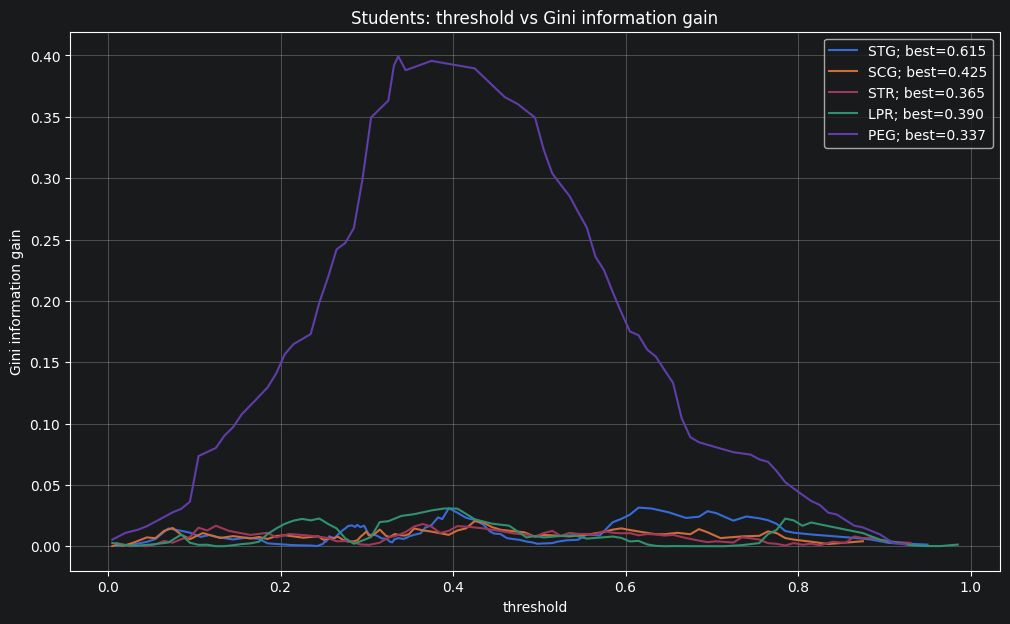

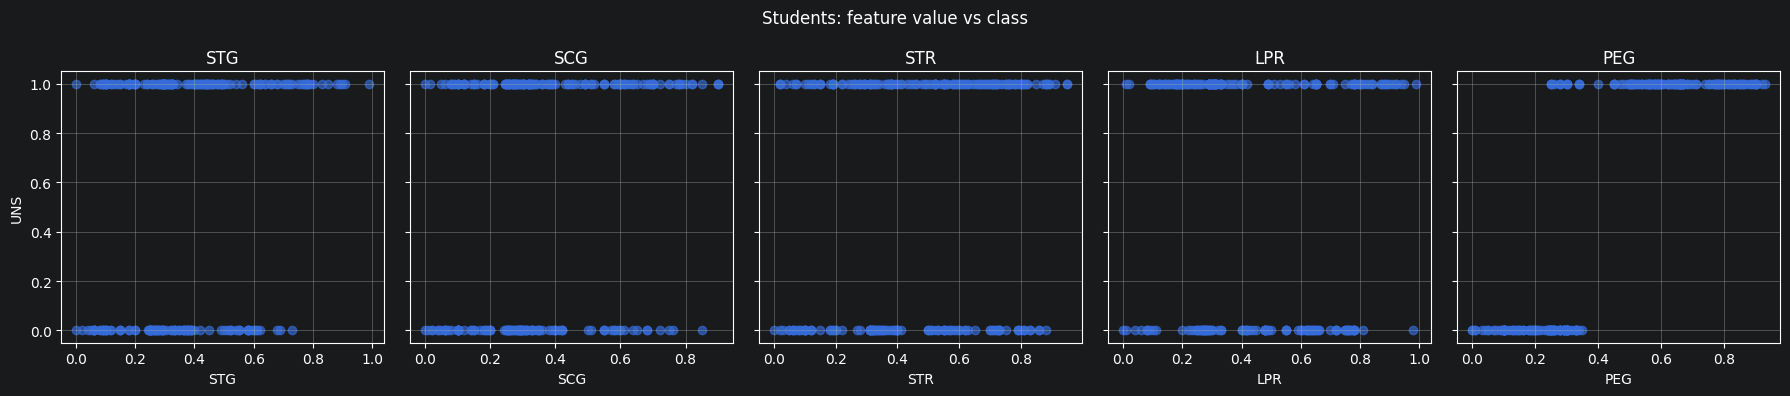

,feature,best_threshold,best_gain
4,PEG,0.3365,0.399392
0,STG,0.6150,0.031481
3,LPR,0.3900,0.030789
1,SCG,0.4250,0.020438
2,STR,0.3650,0.018119


In [116]:
students = pd.read_csv("students.csv")
students = students.drop(columns=["Unnamed: 0"], errors="ignore")
feature_cols = students.columns[:-1]
target_col = students.columns[-1]

plt.figure(figsize=(12, 7))
students_best_splits = []
for col in feature_cols:
    thresholds, gains, threshold_best, gain_best = find_best_split(
        students[col].values, students[target_col].values, task="classification", feature_type="real"
    )
    plt.plot(thresholds, gains, label=f"{col}; best={threshold_best:.3f}")
    students_best_splits.append({"feature": col, "best_threshold": threshold_best, "best_gain": gain_best})

plt.title("Students: threshold vs Gini information gain")
plt.xlabel("threshold")
plt.ylabel("Gini information gain")
plt.legend()
plt.grid(True)
plt.show()

fig, axes = plt.subplots(1, len(feature_cols), figsize=(18, 4), sharey=True)
for ax, col in zip(axes, feature_cols):
    ax.scatter(students[col], students[target_col], alpha=0.65)
    ax.set_title(col)
    ax.set_xlabel(col)
    ax.grid(True)
axes[0].set_ylabel(target_col)
plt.suptitle("Students: feature value vs class")
plt.tight_layout()
plt.show()

students_best_splits_df = pd.DataFrame(students_best_splits).sort_values("best_gain", ascending=False)
display(students_best_splits_df)

Исходя из кривых значений критерия Джини, по какому признаку нужно производить деление выборки на два поддерева? Согласуется ли этот результат с визуальной оценкой диаграмм рассеяиния? Как бы охарактеризовали вид кривой для "хороших" признаков, по которым выборка делится почти идеально? Чем отличаются кривые для признаков, по которым деление практически невозможно?

Лучший первый сплит получается по признаку `PEG` с порогом `0.3365` и приростом Джини `0.3994`. Он наилучший, потому что его пик на графике критерия выше, чем у остальных признаков: при этом пороге дочерние вершины становятся наиболее «чистыми» по классам. Это согласуется с диаграммами рассеяния: для `PEG` классы заметнее разделяются по горизонтальной оси. Для хороших признаков кривая прироста имеет выраженный высокий пик, а для слабых признаков кривая почти плоская и близка к нулю, потому что почти любой порог оставляет смешанные классы

**Задание 2.4 (1 балл)** Протестируйте свое решающее дерево на датасете [mushrooms](https://archive.ics.uci.edu/ml/datasets/Mushroom). 

1. Скачайте таблицу `agaricus-lepiota.data` (находится в директории с ноутбуком), 
2. Считайте таблицу при помощи `pandas`,
3. Примените к каждому столбцу `LabelEncoder` (из `sklearn`), чтобы преобразовать строковые имена категорий в натуральные числа. 

Первый столбец - это целевая переменная (e - edible, p - poisonous) Мы будем измерять качество с помощью accuracy, так что нам не очень важно, что будет классом 1, а что - классом 0. Обучите решающее дерево на половине случайно выбранных объектов (признаки в датасете категориальные) и сделайте предсказания для оставшейся половины. Вычислите accuracy.

In [129]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score

mushrooms_raw = pd.read_csv("agaricus-lepiota.data", header=None)
mushrooms_encoded = mushrooms_raw.copy()
encoders = {}
for col in mushrooms_encoded.columns:
    encoder = LabelEncoder()
    mushrooms_encoded[col] = encoder.fit_transform(mushrooms_encoded[col])
    encoders[col] = encoder

X_mush = mushrooms_encoded.iloc[:, 1:].values
y_mush = mushrooms_encoded.iloc[:, 0].values

X_mush_train, X_mush_test, y_mush_train, y_mush_test = train_test_split(
    X_mush, y_mush, test_size=0.5, random_state=42, stratify=y_mush
)

my_tree = DecisionTree(feature_types=["categorical"] * X_mush.shape[1], task="classification")
my_tree.fit(X_mush_train, y_mush_train)
y_mush_pred = my_tree.predict(X_mush_test)

mushroom_accuracy = accuracy_score(y_mush_test, y_mush_pred)
print(f"Mushrooms accuracy: {mushroom_accuracy:.4f}")
print("Feature importances", np.round(my_tree.feature_importances_, 4))

Mushrooms accuracy: 1.0000
Feature importances [0.     0.002  0.     0.0422 0.6105 0.     0.0271 0.0072 0.     0.
 0.169  0.     0.1009 0.     0.     0.     0.     0.     0.     0.0411
 0.     0.    ]


## Часть 3: Бэггинг и случайный лес (4 балла)

В данной части мы будем работать [с задачей предсказания диабета у пациента](https://www.kaggle.com/uciml/pima-indians-diabetes-database/data). Посмотрим на работу бэггинга над решающими деревьями и случайного леса, сравним их работу.

In [119]:
from sklearn.ensemble import BaggingClassifier, RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, roc_auc_score
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier

In [120]:
data = pd.read_csv('diabetes.csv')
print(f"Dataset shape: {data.shape}")
data.head()

Dataset shape: (768, 9)


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


Посмотрим на распределение целевой переменной

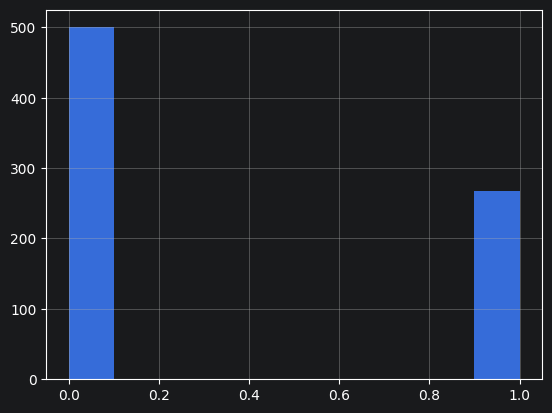

In [121]:
data['Outcome'].hist()
plt.show()

На гистограмме видно, что классы распределены неравномерно: объектов без диабета (`0`) больше, чем объектов с диабетом (`1`). Поэтому дальше важно использовать стратифицированное разбиение и смотреть не только на `accuracy`, но и на `precision`, `recall`, `F1` и `ROC AUC`: простая доля правильных ответов может быть слишком оптимистичной на несбалансированных данных

**Задание 3.1 (0.5 балла)** Разделите данные на признаки и целевую переменную. Разбейте датасет на обучающую и тестовую части в отношении 7:3. Затем разделите обучающую выборку на обучающую-обучающую и обучающую-валидационную в соотношении 7:3 (то есть в итоге должно получиться три выборки: обучающая-обучающая (0.49 от исходного датасета), обучающая-валидационная (0.21 от исходного датасета) и тестовая (0.3 от исходного датасета).

In [122]:
X_diabetes = data.drop(columns=["Outcome"])
y_diabetes = data["Outcome"]

X_train_full, X_test, y_train_full, y_test = train_test_split(
    X_diabetes, y_diabetes, test_size=0.30, random_state=42, stratify=y_diabetes
)
X_train_train, X_valid, y_train_train, y_valid = train_test_split(
    X_train_full, y_train_full, test_size=0.30, random_state=42, stratify=y_train_full
)

print("Full dataset:", X_diabetes.shape, y_diabetes.shape)
print("Train-train:", X_train_train.shape, y_train_train.shape)
print("Validation:", X_valid.shape, y_valid.shape)
print("Test:", X_test.shape, y_test.shape)

Full dataset: (768, 8) (768,)
Train-train: (375, 8) (375,)
Validation: (162, 8) (162,)
Test: (231, 8) (231,)


Получились три выборки нужного размера: обучающая-обучающая - 375 объектов, валидационная - 162 объекта, тестовая - 231 объект. Параметр `stratify` сохраняет примерно одинаковую долю классов во всех частях, поэтому сравнение моделей получается более честнм

**Задание 3.2 (1 балл)** На обучающей-валидационной выборке подберите оптимальные значения гиперпараметров `max_depth` и `min_samples_leaf` для `DecisionTreeClassifier`. Для этого:
1. Создайте списки с возможными значениями для перебора.
2. Для каждой пары значений обучите дерево на обучающей-обучающей выборке и определите качество на обучающей-валидационной выборке. В качестве критерия будем использовать `f1-меру`.
3. Выберите ту пару значений, которая даёт наилучшее качество на обучающей-валидационной выборке. 


Обучите решающее дерево с подобранными гиперпараметрами на **полной обучающей** выборке. Оцените качество классификации на тестовой выборке по метрикам `accuracy`, `precision` и `recall`, `auc_roc`.

In [ ]:
from sklearn.metrics import f1_score


def evaluate_classifier(model, X_test, y_test, model_name: str) -> Dict[str, float]:
    y_pred = model.predict(X_test)
    if hasattr(model, "predict_proba"):
        y_score = model.predict_proba(X_test)[:, 1]
    else:
        y_score = y_pred
    metrics = {
        "model": model_name,
        "accuracy": accuracy_score(y_test, y_pred),
        "precision": precision_score(y_test, y_pred, zero_division=0),
        "recall": recall_score(y_test, y_pred, zero_division=0),
        "roc_auc": roc_auc_score(y_test, y_score),
        "f1": f1_score(y_test, y_pred),
    }
    return metrics

max_depth_grid = [2, 3, 4, 5, 6, 8, 10, None]
min_samples_leaf_grid = [1, 2, 3, 5, 10, 15, 20]

dt_grid_results = []
for max_depth in max_depth_grid:
    for min_samples_leaf in min_samples_leaf_grid:
        dt = DecisionTreeClassifier(
            max_depth=max_depth,
            min_samples_leaf=min_samples_leaf,
            random_state=42,
        )
        dt.fit(X_train_train, y_train_train)
        y_valid_pred = dt.predict(X_valid)
        dt_grid_results.append({
            "max_depth": max_depth,
            "min_samples_leaf": min_samples_leaf,
            "valid_f1": f1_score(y_valid, y_valid_pred),
        })

dt_grid_results_df = pd.DataFrame(dt_grid_results).sort_values("valid_f1", ascending=False).reset_index(drop=True)
display(dt_grid_results_df.head(10))

# Выбираем параметры по таблице выше: максимальная valid_f1 достигается при min_samples_leaf = 20.
best_dt_max_depth = None
best_dt_min_samples_leaf = 20
best_dt_params = {"max_depth": best_dt_max_depth, "min_samples_leaf": best_dt_min_samples_leaf}

dt_best = DecisionTreeClassifier(
    max_depth=best_dt_max_depth,
    min_samples_leaf=best_dt_min_samples_leaf,
    random_state=42,
)
dt_best.fit(X_train_full, y_train_full)

dt_metrics = evaluate_classifier(dt_best, X_test, y_test, "DecisionTree")
display(pd.DataFrame([dt_metrics]))

По таблице видно, что максимальное значение `valid_f1 = 0.625` достигается сразу у нескольких вариантов глубины при `min_samples_leaf=20`. Я оставил `max_depth=None`, `min_samples_leaf=20`: этот вариант находится среди лучших по `F1`, а большой размер листа дополнительно ограничивает слишком мелкие разбиения и снижает риск переобучения. На тесте дерево показывает `F1 = 0.613`, `ROC AUC = 0.797`: качество умеренное, recall ниже precision, то есть модель осторожнее предсказывает положительный класс


**Задание 3.3 (0.5 балла)** Обучите [`BaggingClassifier`](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.BaggingClassifier.html) на 50 деревьях на **полной обучающей** выборке. Оцените качество классификации на тестовой выборке по тем же метрикам.

In [ ]:
bagging = BaggingClassifier(
    estimator=DecisionTreeClassifier(random_state=42),
    n_estimators=50,
    random_state=42,
    n_jobs=1,
)
bagging.fit(X_train_full, y_train_full)

bagging_metrics = evaluate_classifier(bagging, X_test, y_test, "Bagging(50 trees)")
pd.DataFrame([dt_metrics, bagging_metrics])

Бэггинг из 50 деревьев немного повышает `accuracy`, `precision` и особенно `ROC AUC` по сравнению с одним деревом. Это ожидаемо: усреднение нескольких деревьев уменьшает разброс модели. При этом `recall` и `F1` стали немного ниже, значит ансамбль стал чуть более осторожным в выдаче положительного класса и пропускает больше пациентов класса `1`

**Задание 3.4 (1 балл)** Выполните кросс-валидацию на полной обучающей выборке и подберите оптимальные значения гиперпараметров `max_depth` и `min_samples_split` для `Random Forest` с 50 деревьями. Для этого:

1. Создайте списки с возможными значениями для перебора.
2. Для каждой пары значений проведите кросс-валидацию на полной обучающей выборке. Количество разбиений выберите на ваш вкус. В качестве критерия будем использовать `f1-меру`. Усредните значение критерия по всем прогонам кросс-валидации. 
3. Выберите ту пару значений, которая даёт наилучшее среднее качество. 

Обучите случайный лес с подобранными гиперпараметрами на **полной обучающей** выборке. Оцените качество классификации по тем же метрикам. Какая из трёх построенных моделей показала себя лучше?

In [ ]:
from sklearn.model_selection import StratifiedKFold, cross_val_score

rf_max_depth_grid = [3, 5, 8, None]
rf_min_samples_split_grid = [2, 10, 20]
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

rf_grid_results = []
for max_depth in rf_max_depth_grid:
    for min_samples_split in rf_min_samples_split_grid:
        rf = RandomForestClassifier(
            n_estimators=50,
            max_depth=max_depth,
            min_samples_split=min_samples_split,
            random_state=42,
            n_jobs=1,
        )
        scores = cross_val_score(rf, X_train_full, y_train_full, cv=cv, scoring="f1", n_jobs=1)
        rf_grid_results.append({
            "max_depth": max_depth,
            "min_samples_split": min_samples_split,
            "cv_f1_mean": scores.mean(),
            "cv_f1_std": scores.std(),
        })

rf_grid_results_df = pd.DataFrame(rf_grid_results).sort_values("cv_f1_mean", ascending=False).reset_index(drop=True)
display(rf_grid_results_df.head(10))

# Выбираем параметры по таблице выше: первая строка даёт максимальную среднюю F1 на кросс-валидации.
best_rf_max_depth = None
best_rf_min_samples_split = 10
best_rf_params = {"max_depth": best_rf_max_depth, "min_samples_split": best_rf_min_samples_split}

rf_best = RandomForestClassifier(
    n_estimators=50,
    max_depth=best_rf_max_depth,
    min_samples_split=best_rf_min_samples_split,
    random_state=42,
    n_jobs=1,
)
rf_best.fit(X_train_full, y_train_full)

rf_metrics = evaluate_classifier(rf_best, X_test, y_test, "RandomForest(50 trees)")
metrics_df = pd.DataFrame([dt_metrics, bagging_metrics, rf_metrics])
display(metrics_df)

По таблице кросс-валидации лучшая пара для Random Forest - `max_depth=None`, `min_samples_split=10`, потому что у неё максимальная средняя `F1`-мера (`0.633`). Увеличенный `min_samples_split` не даёт деревьям дробить вершины слишком агрессивно и помогает бороться с переобучением. В таблице тестовых метрик видно, что по `F1` лучшим оказалось одиночное дерево (`0.613`), а по `ROC AUC` - бэггинг (`0.827`). Поэтому если важнее качество ранжирования вероятностей, лучше выглядит бэггинг; если ориентироваться строго на `F1` при пороге 0.5, лучшим в этом запуске оказалось дерево решений

**Задание 3.5 (0.5 балла)** Постройте график зависимости AUC ROC на тестовой выборке от числа деревьев (`n_estimators`) для случайного леса, обучаемого на **полной обучающей** выборке. Какие выводы можно сделать?

In [ ]:
n_estimators_grid = [1, 5, 10, 20, 30, 50, 75, 100]
auc_scores = []
for n_estimators in n_estimators_grid:
    rf = RandomForestClassifier(
        n_estimators=n_estimators,
        max_depth=best_rf_max_depth,
        min_samples_split=best_rf_min_samples_split,
        random_state=42,
        n_jobs=1,
    )
    rf.fit(X_train_full, y_train_full)
    auc_scores.append(roc_auc_score(y_test, rf.predict_proba(X_test)[:, 1]))

plt.figure(figsize=(10, 6))
plt.plot(n_estimators_grid, auc_scores, marker="o")
plt.title("Random Forest: test ROC AUC vs number of trees")
plt.xlabel("n_estimators")
plt.ylabel("test ROC AUC")
plt.grid(True)
plt.show()

auc_scores_df = pd.DataFrame({
    "n_estimators": n_estimators_grid,
    "test_roc_auc": auc_scores,
}).sort_values("test_roc_auc", ascending=False).reset_index(drop=True)
display(auc_scores_df)


На графике качество быстро растёт при малом числе деревьев, а затем выходит на плато: после примерно 50 деревьев добавление новых деревьев даёт небольшой выигрыш. По таблице максимальный `ROC AUC` на проверенной сетке получился при `n_estimators=50` (`0.8207`). При этом значения для 50, 75 и 100 деревьев очень близки, поэтому практически можно использовать 50–100 деревьев: качество уже стабилизировалось

**Задание 3.6 (0.5 балла)** Для лучшей модели случайного леса из **Задания 3.4** посчитайте важность признаков и постройте bar plot. Какой признак оказался самым важным для определения диабета?

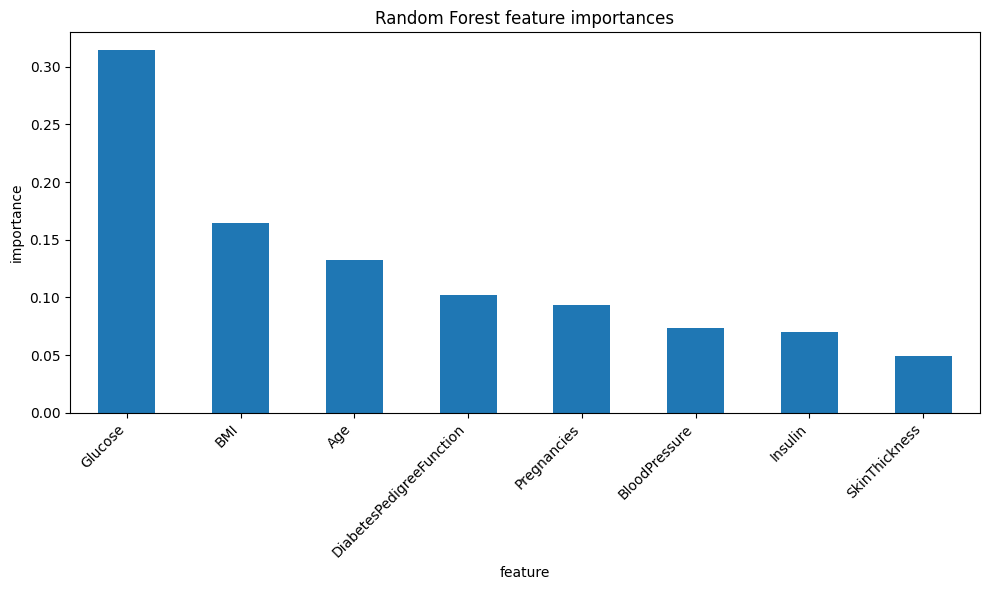

,feature,importance
0,Glucose,0.314238
1,BMI,0.164451
2,Age,0.132683
3,DiabetesPedigreeFunction,0.102268
4,Pregnancies,0.093567
5,BloodPressure,0.073561
6,Insulin,0.069927
7,SkinThickness,0.049305


In [127]:
feature_importances = pd.Series(rf_best.feature_importances_, index=X_train_full.columns).sort_values(ascending=False)

plt.figure(figsize=(10, 6))
feature_importances.plot(kind="bar")
plt.title("Random Forest feature importances")
plt.xlabel("feature")
plt.ylabel("importance")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

feature_importances_df = feature_importances.rename("importance").reset_index().rename(columns={"index": "feature"})
display(feature_importances_df)


Самый важный признак - `Glucose`: в таблице он стоит на первом месте, а на bar plot его столбец самый высокий (`importance ≈ 0.314`). Это значит, что разбиения по уровню глюкозы чаще и сильнее уменьшают неопределённость в деревьях случайного леса. Следующие по важности признаки - `BMI` и `Age`, но их вклад заметно меньше